# Unobserved Confounding Example

obs_df: DataFrame with columns 'treatment_obs' (T_i) and 'y_obs' (Y_i)
Model: Y_i = θ · T_i + z_i + ε_i where:
  - T_i ∈ {0, 1}
  - z_i ~ N(0, σ²) unobserved
 - Y_i observed with p(1/(1+e^(-z_i)))
  - ε_i ~ N(0, 0.5²)


In [1]:
import os
os.environ['KERAS_BACKEND'] = 'jax'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm
from cmdstanpy import CmdStanModel

import keras
import bayesflow as bf

INFO:bayesflow:Using backend 'jax'


In [2]:
# Parameters
np.random.seed(42)
n_population = 1000  # Full population size
n_samples = 100
#observed_covariates = np.exp(np.random.normal(size=n_population))
param_names = ['treatment_effect', 'health_awareness']

def selection_probability(z):
    """Calculate selection probability p(1/(1+e^(-z)))"""
    return 1 / (1 + np.exp(-z))

def clinical_trial_model(treatment_effect: float = 1.7, health_awareness: float = 1.):
    # Generate true population PedCov
    z = health_awareness * np.random.normal(0, 1, n_population)
    treatment = np.random.binomial(1, 0.5, n_population)
    epsilon = np.random.normal(0, 0.5, n_population)
    y = treatment_effect * treatment + z + epsilon
    prob_obs = selection_probability(z)
    selected = np.random.binomial(1, prob_obs)
    # Observed PedCov
    y_obs = y[selected == 1]
    treatment_obs = treatment[selected == 1]
    selected_index = np.random.choice(np.arange(len(y_obs)), n_samples, replace=False)
    
    # Create the observed sample PedCov
    observed_data = pd.DataFrame({
        'treatment_obs': treatment_obs[selected_index],
        'y_obs': y_obs[selected_index],
        #'observed_covariates': observed_covariates[selected == 1][selected_index],
        'unobserved_confounder': z[selected == 1][selected_index]
    })
    
    # Full population PedCov (for reference)
    population_data = pd.DataFrame({
        'treatment_obs': treatment,
        'y_obs': y,
        #'observed_covariates': observed_covariates,
        'unobserved_confounder': z
    })
    return observed_data, population_data

obs, pop = clinical_trial_model()
print(obs.shape)

(100, 3)


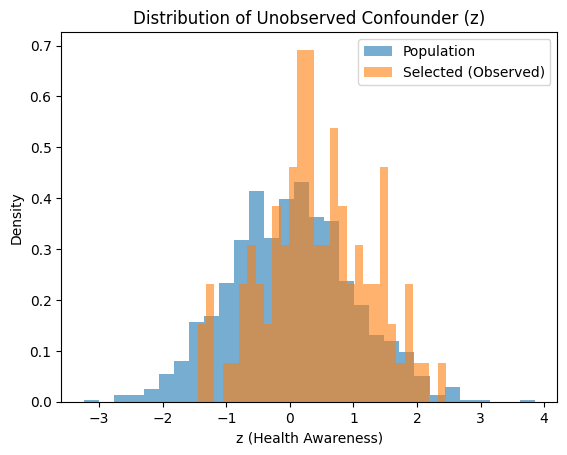

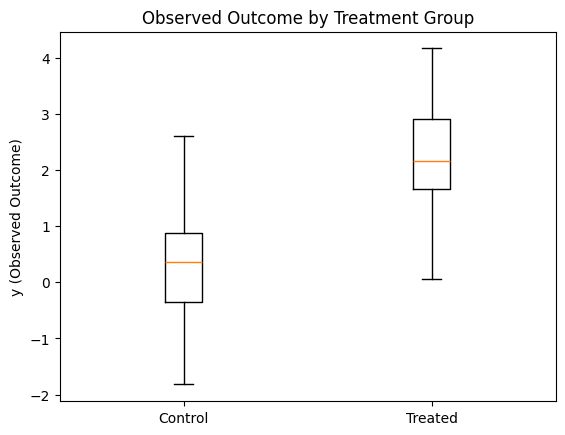

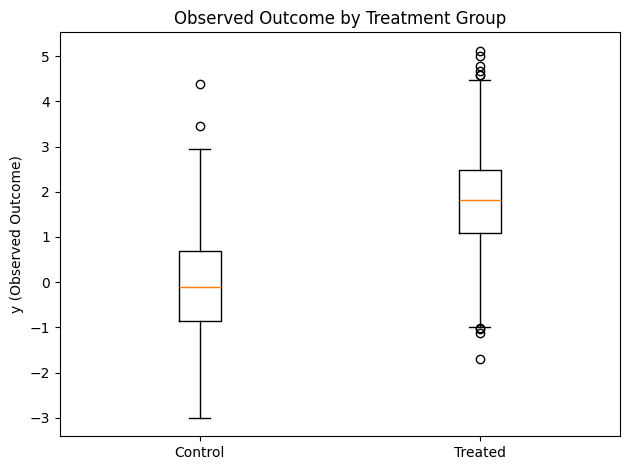

In [3]:
# Plot 1: Population vs Observed Distribution of Unobserved Confounder
fig1, ax1 = plt.subplots()
ax1.hist(pop["unobserved_confounder"], bins=30, alpha=0.6, label="Population", density=True)
ax1.hist(obs["unobserved_confounder"], bins=30, alpha=0.6, label="Selected (Observed)", density=True)
ax1.set_title("Distribution of Unobserved Confounder (z)")
ax1.set_xlabel("z (Health Awareness)")
ax1.set_ylabel("Density")
ax1.legend()

# Plot 2: Treatment vs Outcome in Observed Data
fig2, ax2 = plt.subplots()
ax2.boxplot([obs[obs["treatment_obs"] == 0]["y_obs"], obs[obs["treatment_obs"] == 1]["y_obs"]],
            tick_labels=["Control", "Treated"])
ax2.set_title("Observed Outcome by Treatment Group")
ax2.set_ylabel("y (Observed Outcome)")

# Plot 2: Treatment vs Outcome in Population Data
fig2, ax2 = plt.subplots()
ax2.boxplot([pop[pop["treatment_obs"] == 0]["y_obs"], pop[pop["treatment_obs"] == 1]["y_obs"]],
            tick_labels=["Control", "Treated"])
ax2.set_title("Observed Outcome by Treatment Group")
ax2.set_ylabel("y (Observed Outcome)")

# Show both plots
plt.tight_layout()
plt.show()

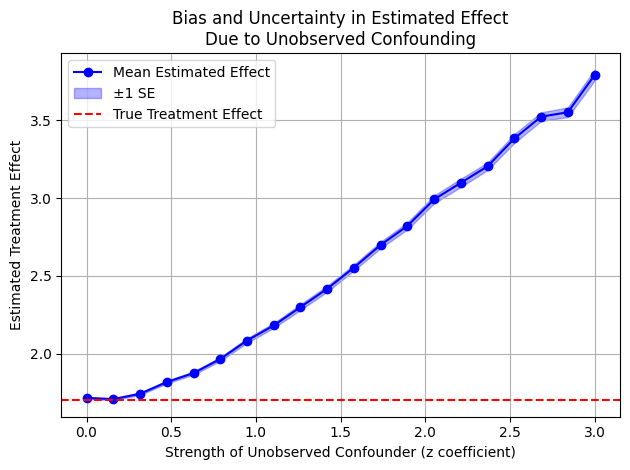

In [4]:
np.random.seed(42)
# Simulate multiple trials for each confounder strength to compute mean and standard error
n_trials = 100
confounder_strengths = np.linspace(0, 3.0, 20)
true_effect = 1.7
mean_effects = []
stderr_effects = []

# Function to compute naive treatment effect in observed PedCov
def estimate_treatment_effect(obs_df):
    treated_mean = obs_df[obs_df["treatment_obs"] == 1]["y_obs"].mean()
    control_mean = obs_df[obs_df["treatment_obs"] == 0]["y_obs"].mean()
    return treated_mean - control_mean

def estimate_treatment_effect_ols(obs_df):
    X = obs_df[["treatment_obs"]] #, "observed_covariates"]]
    #X = sm.add_constant(X)
    y = obs_df["y_obs"]
    model = sm.OLS(y, X).fit()
    return model.params["treatment_obs"] #, model.bse["treatment_obs"]

for strength in confounder_strengths:
    estimates = []
    for _ in range(n_trials):
        obs_df, _ = clinical_trial_model(treatment_effect=true_effect, health_awareness=strength)
        est_effect = estimate_treatment_effect_ols(obs_df)
        estimates.append(est_effect)
    estimates = np.array(estimates)
    mean_effects.append(estimates.mean())
    stderr_effects.append(estimates.std(ddof=1) / np.sqrt(n_trials))

# Plot: Estimated Treatment Effect with Standard Error Bands
fig, ax = plt.subplots()
ax.plot(confounder_strengths, mean_effects, label="Mean Estimated Effect", color="blue", marker='o')
ax.fill_between(confounder_strengths,
                np.array(mean_effects) - np.array(stderr_effects),
                np.array(mean_effects) + np.array(stderr_effects),
                color="blue", alpha=0.3, label="±1 SE")
ax.axhline(true_effect, color='red', linestyle='--', label="True Treatment Effect")
ax.set_xlabel("Strength of Unobserved Confounder (z coefficient)")
ax.set_ylabel("Estimated Treatment Effect")
ax.set_title("Bias and Uncertainty in Estimated Effect\nDue to Unobserved Confounding")
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
prior_range = [0., 3.]
def generative_model(batch_size, health_awareness=None):
    param_batch = np.random.uniform(prior_range[0], prior_range[1], size=(batch_size, len(param_names)))
    if not health_awareness is None:  # we overwrite the samples
        param_batch[:, 1] = health_awareness

    # Initialize PedCov array
    data = np.zeros((len(param_batch), n_samples, 2))
    dfs = []
    for i_p, param in enumerate(param_batch):
        # Generate PedCov for the clinical model with the given parameter
        # Unpack the parameters
        treatment_effect, _health_awareness = param

        data_i, _ = clinical_trial_model(treatment_effect, health_awareness=_health_awareness)
        data[i_p] = data_i[['y_obs', 'treatment_obs']].values
        dfs.append(data_i)
    return {'sim_data': data, 'prior_draws': param_batch, 'obs_df': dfs}

In [6]:
np.random.seed(42)
valid_data = generative_model(100)

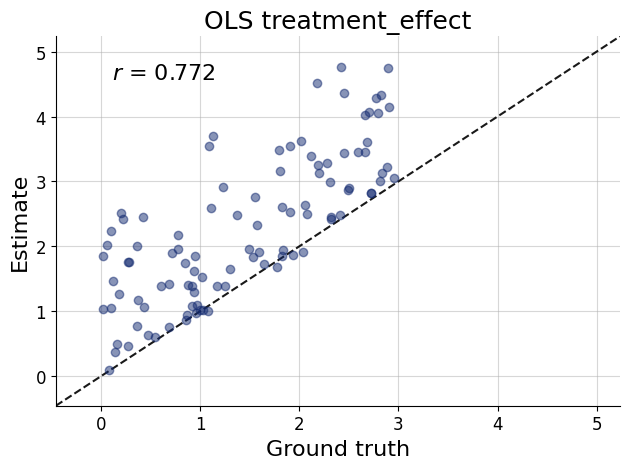

In [7]:
estimates_OLS = []
for obs_df in valid_data['obs_df']:
    est_effect = estimate_treatment_effect_ols(obs_df)
    estimates_OLS.append(est_effect)
estimates_OLS = np.array(estimates_OLS).reshape(len(valid_data['obs_df']), 1, 1)

bf.diagnostics.recovery(estimates_OLS, valid_data['prior_draws'][:, :1], variable_names=['OLS ' + p for p in param_names[:1]]);

In [8]:
# # ------------ MAXIMUM LIKELIHOOD ESTIMATION ------------
#
# def negative_log_likelihood(params, treatment, y_obs):
#     """
#     Calculate the negative log likelihood for the observed PedCov
#
#     params[0]: theta
#     params[1]: sigma (standard deviation of z)
#     """
#     theta, sigma = params
#
#     n_obs = len(y_obs)
#     ll = 0
#
#     for i in range(n_obs):
#         t_i = treatment[i]
#         y_i = y_obs[i]
#
#         # Define the integrand function: f(z) = p(selection|z) * p(y|z,t) * p(z)
#         def integrand(z):
#             # Selection probability
#             p_selection = selection_probability(z)
#
#             # Likelihood of y given z and t: p(y|z,t) ~ N(θ·t + z, 0.5²)
#             p_y_given_z_t = stats.norm.pdf(y_i, loc=theta*t_i + z, scale=0.5)
#
#             # Prior on z: p(z) ~ N(0, σ²)
#             p_z = stats.norm.pdf(z, loc=0, scale=sigma)
#
#             return p_selection * p_y_given_z_t * p_z
#
#         # Integrate over z (numerically)
#         # We integrate over a reasonable range: ±5σ should cover most of the mass
#         z_range = 5 * sigma
#         integral_result, _ = quad(integrand, -z_range, z_range)
#
#         # Add log probability to the log likelihood
#         ll += np.log(max(integral_result, 1e-10))  # Avoid log(0)
#
#     return -ll  # Return negative log likelihood for minimization
#
# def fit_mle(obs_df):
#     """Fit the model using MLE"""
#     treatment = obs_df['treatment_obs'].values
#     y_obs = obs_df['y_obs'].values
#
#     # Initial parameter guess [theta, sigma]
#     initial_params = [0.0, 1.0]
#
#     # Bounds for parameters (theta can be any real number, sigma must be positive)
#     bounds = [(None, None), (0.01, None)]
#
#     # Minimize negative log likelihood
#     result = minimize(
#         negative_log_likelihood,
#         initial_params,
#         args=(treatment, y_obs),
#         bounds=bounds,
#         method='L-BFGS-B'
#     )
#
#     theta_mle, sigma_mle = result.x
#
#     return {
#         'theta': theta_mle,
#         'sigma': sigma_mle,
#         'convergence': result.success,
#         'log_likelihood': -result.fun
#     }
#
#
# prior_draws = np.random.uniform(0, 3, 100)
# estimates = []
#
# for true_effect in tqdm(prior_draws):
#     obs_df, _ = clinical_trial_model(treatment_effect=true_effect, health_awareness=np.random.uniform(0, 3))
#     mle_results = fit_mle(obs_df)
#     estimates.append(mle_results['theta'])
# estimates = np.array(estimates).reshape(-1, 1, 1)
#
# bf.diagnostics.plot_recovery(estimates, prior_draws.reshape(-1, 1), param_names=['MLE treatment_effect']);

15:13:28 - cmdstanpy - INFO - compiling stan file /var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmputnvdt77/tmpxhtarmfw.stan to exe file /Users/jonas.arruda/PyCharm Projects/SamplingBias/unobserved_stan_model
INFO:cmdstanpy:compiling stan file /var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmputnvdt77/tmpxhtarmfw.stan to exe file /Users/jonas.arruda/PyCharm Projects/SamplingBias/unobserved_stan_model
DEBUG:cmdstanpy:cmd: make STANCFLAGS+=--filename-in-msg=unobserved_stan_model.stan /var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmputnvdt77/tmpxhtarmfw
cwd: /Users/jonas.arruda/.cmdstan/cmdstan-2.36.0
DEBUG:cmdstanpy:Console output:

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=unobserved_stan_model.stan --o=/var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmputnvdt77/tmpxhtarmfw.hpp /var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/tmputnvdt77/tmpxhtarmfw.stan

--- Compiling C++ code ---
clang++ -std=c++17 -Wno-unknown-warning-option -Wno-tautological-com

CPU times: user 9.21 s, sys: 5.71 s, total: 14.9 s
Wall time: 1min 27s


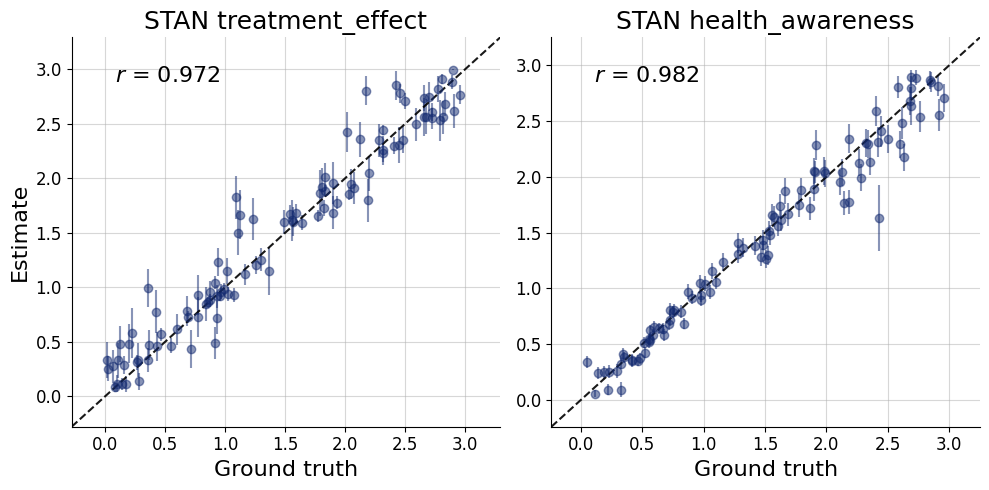

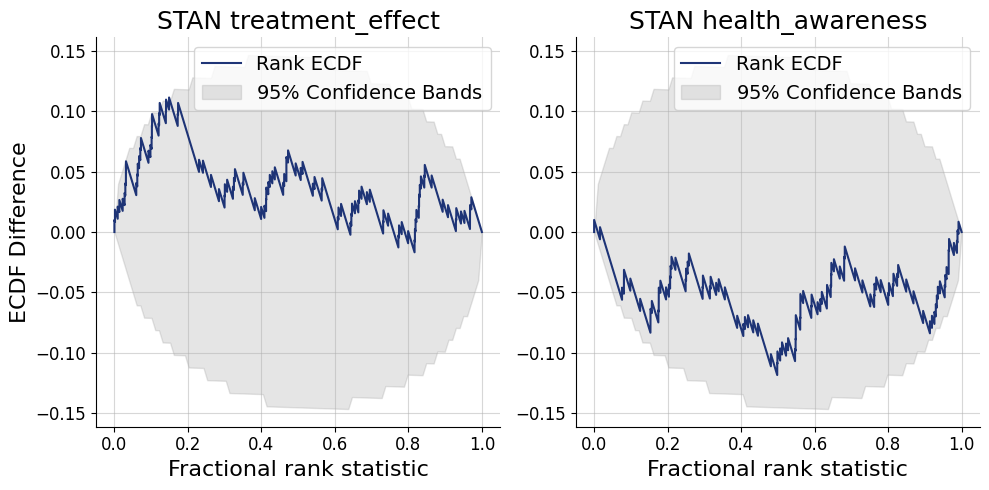

In [9]:
%%time

stan_model = CmdStanModel(stan_file='unobserved_stan_model.stan')
def get_stan_posterior(obs_df, chains=4):

    # Prepare PedCov for Stan
    stan_data = {
        'N': obs_df.shape[0],
        'T': obs_df['treatment_obs'].values,
        'Y': obs_df['y_obs'].values,
    }

    # Fit the model to the PedCov
    fit = stan_model.sample(data=stan_data, show_progress=False, chains=chains)

    if len(param_names) == 1:
        return np.array(fit.draws_pd("theta"))
    return np.concatenate((fit.draws_pd("theta"), fit.draws_pd("sigma")), axis=-1)

estimates_STAN = []
for obs_df in tqdm(valid_data['obs_df']):
    est_effect = get_stan_posterior(obs_df)
    estimates_STAN.append(est_effect)
estimates_STAN = np.array(estimates_STAN).reshape(len(valid_data['obs_df']), -1, len(param_names))

bf.diagnostics.recovery(estimates_STAN, valid_data['prior_draws'], variable_names=['STAN ' + p for p in param_names])
bf.diagnostics.calibration_ecdf(estimates_STAN, valid_data['prior_draws'], difference=True, variable_names=['STAN ' + p for p in param_names]);

# Use BayesFlow

In [10]:
%%time
training_data = generative_model(10000)

CPU times: user 3.56 s, sys: 87.6 ms, total: 3.65 s
Wall time: 3.66 s


In [11]:
variable_names = ['Treatment Effect', 'Latent Confounder Variance']

In [12]:
adapter = (
    bf.adapters.Adapter()
    .drop('obs_df')
    .to_array()
    .convert_dtype(from_dtype="float64", to_dtype="float32")
    .constrain("prior_draws", lower=0, upper=3, inclusive='both')
    .rename('prior_draws', to_key="inference_variables")
    .concatenate('sim_data', into="summary_variables")
)

In [14]:
workflow = bf.BasicWorkflow(
    #simulator=generative_model,
    adapter=adapter,
    summary_network=bf.networks.DeepSet(summary_dim=5),
    #inference_network=bf.networks.CouplingFlow(depth=5)
    inference_network=bf.networks.FlowMatching()
)

In [15]:
model_path = f'models/unobserved_variable_fm.keras'
if os.path.exists(model_path):
    workflow.approximator = keras.saving.load_model(filepath=model_path)
else:
    history = workflow.fit_offline(
        data=training_data,
        epochs=25,
        batch_size=64,
        validation_data=valid_data,
    )
    workflow.approximator.save(model_path)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - loss: 61.3583 - val_loss: 1.6945
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.6984 - val_loss: 1.7231
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.3208 - val_loss: 1.0200
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 1.2046 - val_loss: 1.1261
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 1.1364 - val_loss: 1.0749
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.1209 - val_loss: 1.2250
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.0928 - val_loss: 1.0549
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 1.0118 - val_loss: 0.7527
Epoch 9/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.7394 - val_loss: 0.7655
Epoch 10/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.6881 - val_loss: 0.5233
Epoch 11/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.6232 - val_loss: 0.5316
Epoch 12/25
157/157 ━━━━━━━━━━━━━━━━━━━

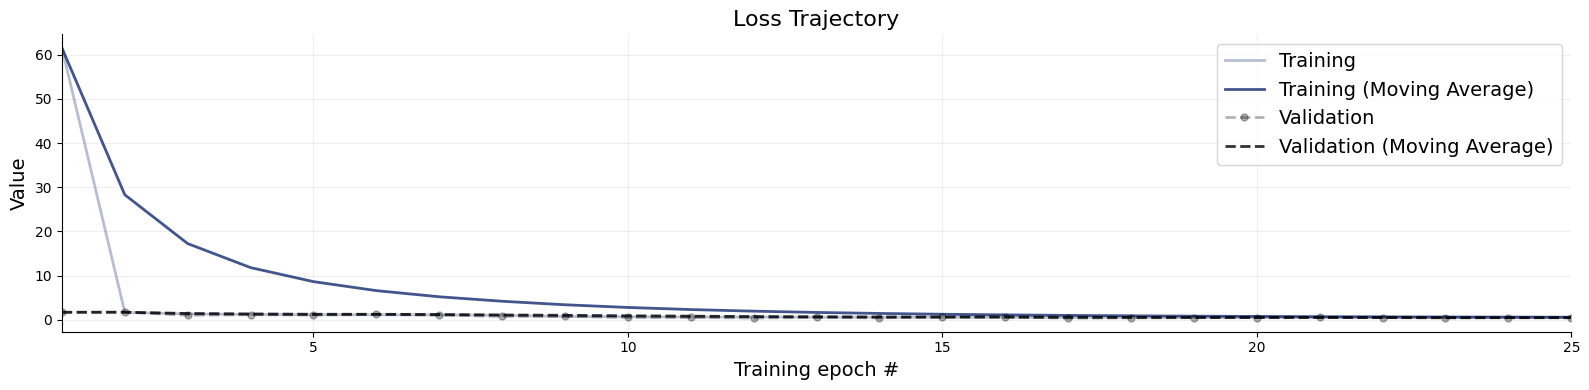

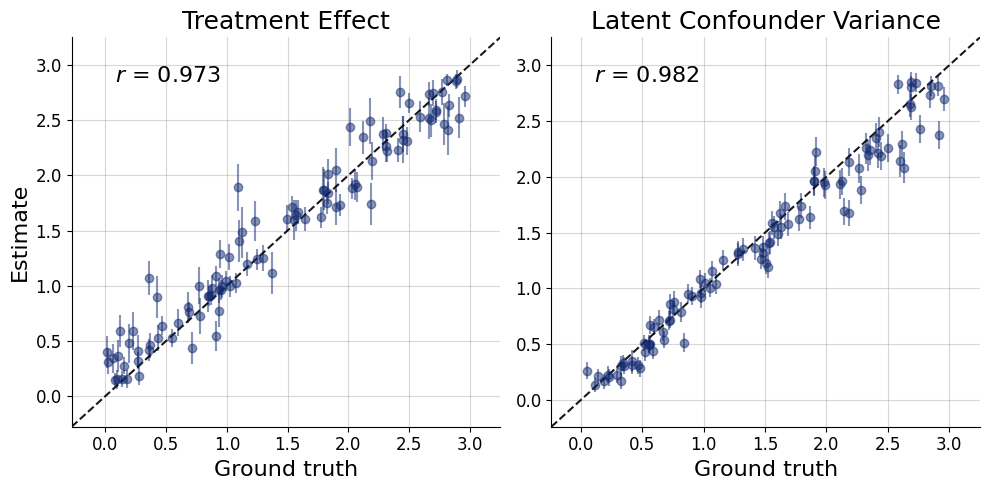

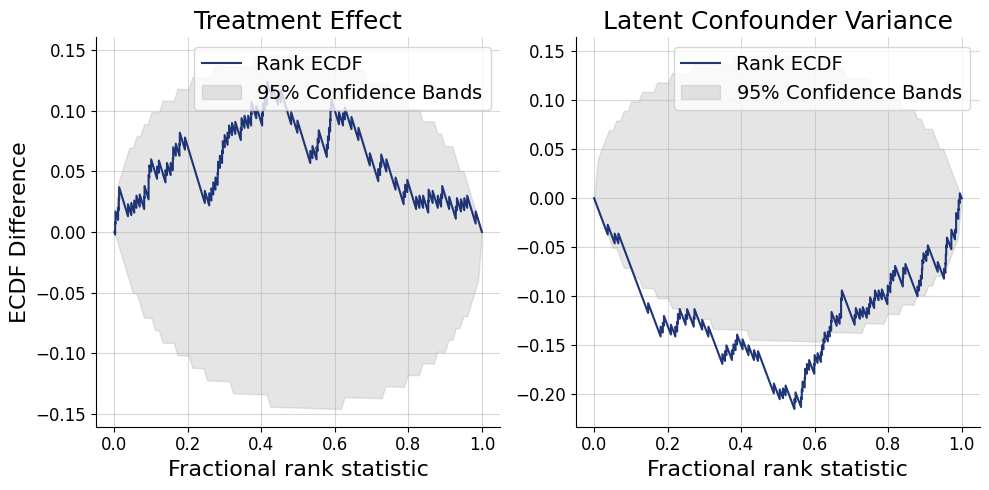

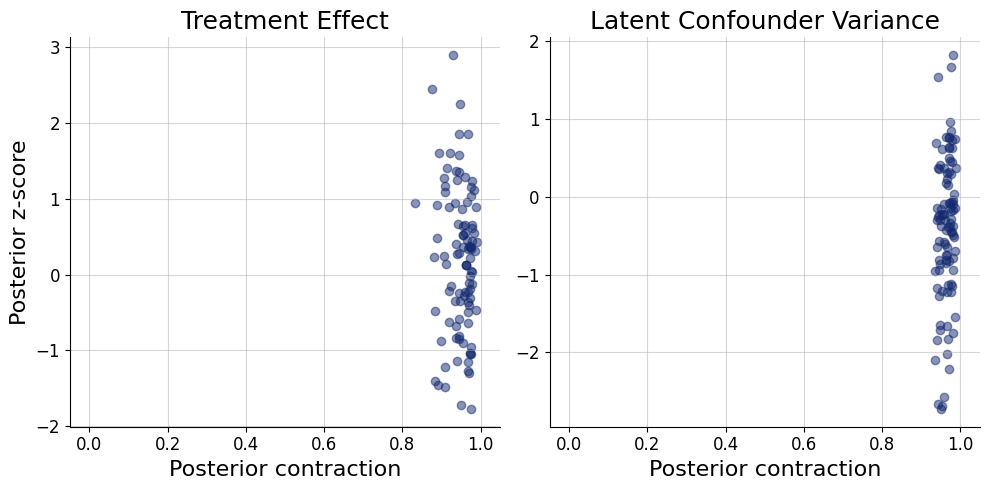

In [16]:
diagnostics = workflow.plot_default_diagnostics(test_data=valid_data, calibration_ecdf_kwargs={'difference': True},
                                                variable_names=variable_names)
#diagnostics['recovery'].savefig('plots/unobserved_recovery.pdf')

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.11/site-packages/bayesflow/diagnostics/plots/z_score_contraction.py:113: RuntimeWarning: divide by zero encountered in divide
  contraction = np.clip(1 - (post_vars / prior_vars), 0, 1)


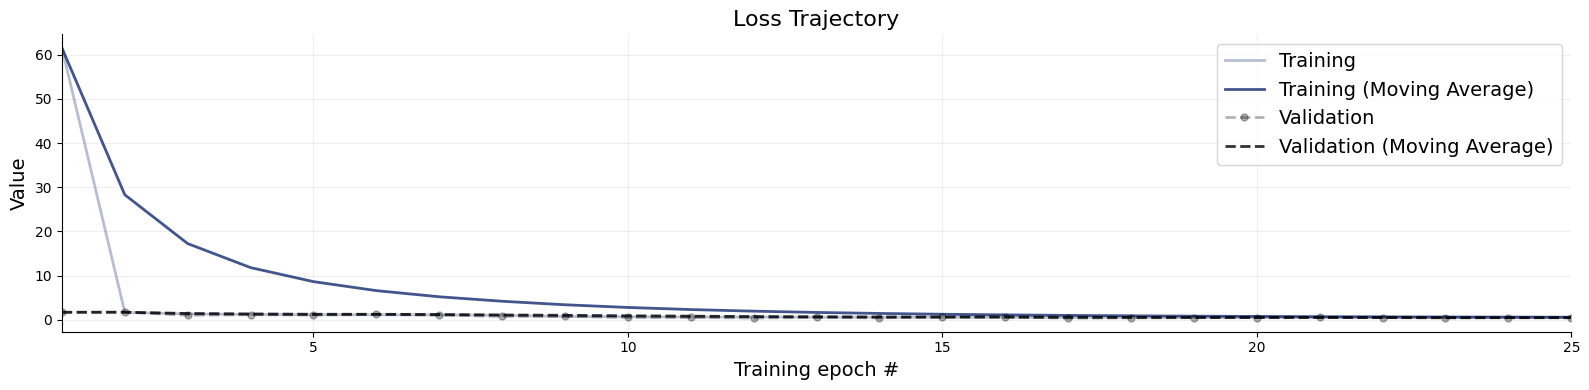

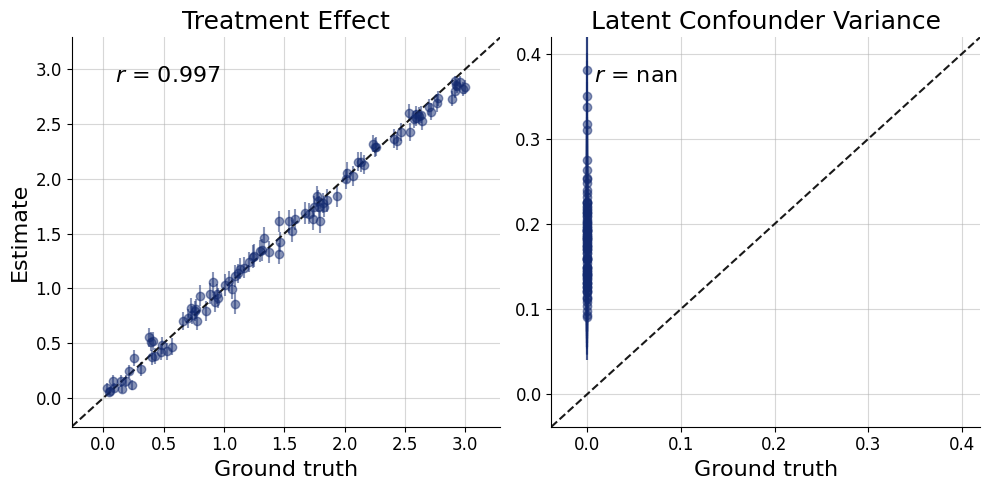

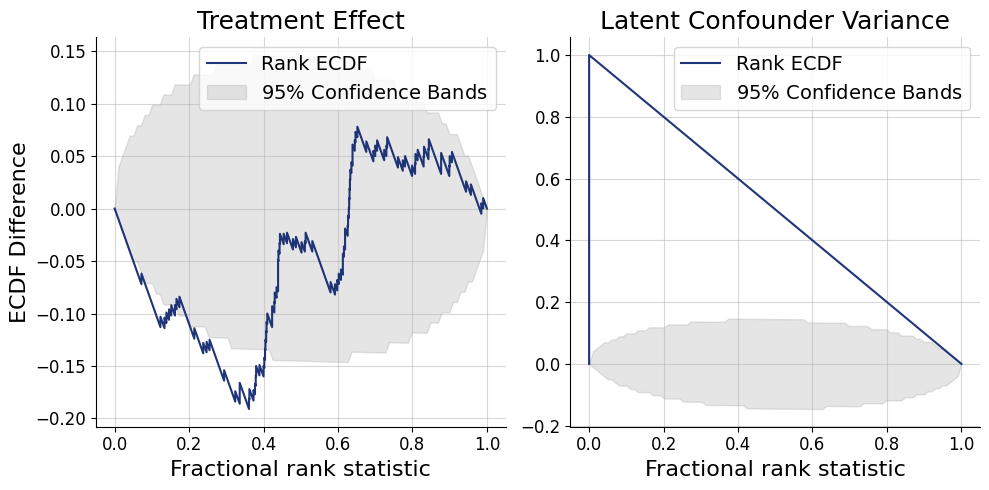

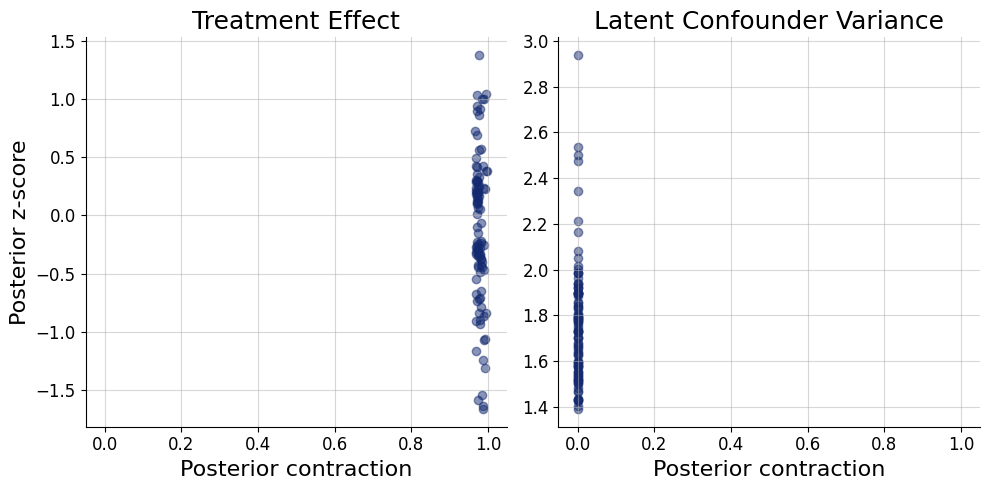

In [17]:
# check what happens when there is no bias
test_data = generative_model(100, health_awareness=0.)
diagnostics = workflow.plot_default_diagnostics(test_data=test_data, calibration_ecdf_kwargs={'difference': True},
                                                variable_names=variable_names)
#diagnostics['recovery'].savefig('plots/unobserved_recovery_unbiased.pdf')

In [18]:
posterior_samples = workflow.sample(num_samples=300, conditions=valid_data)

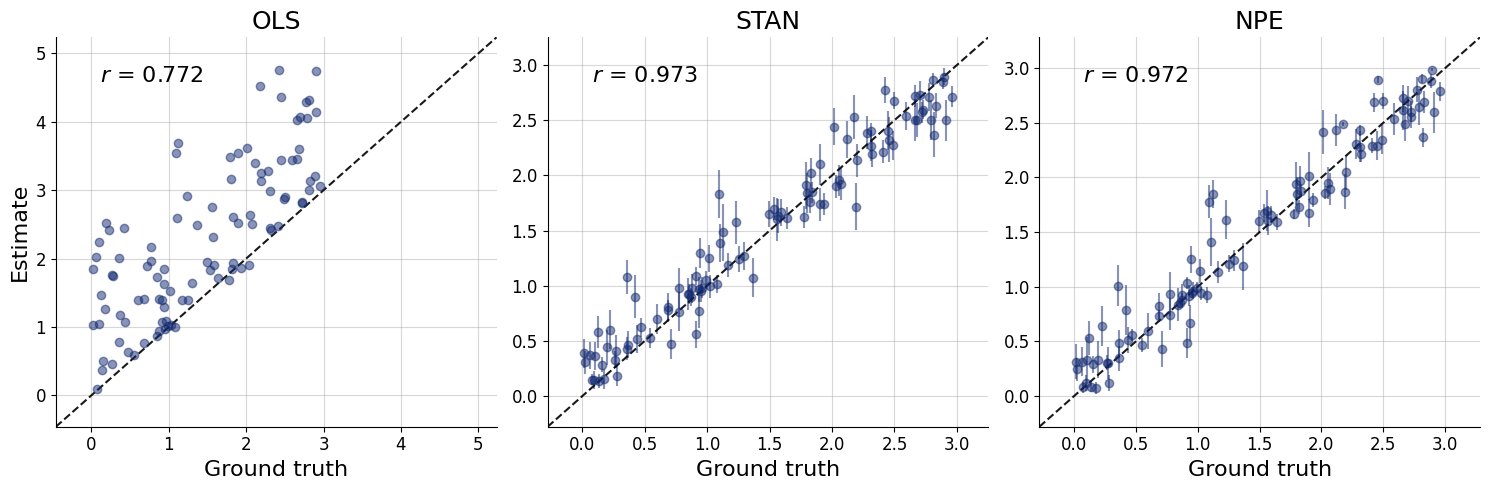

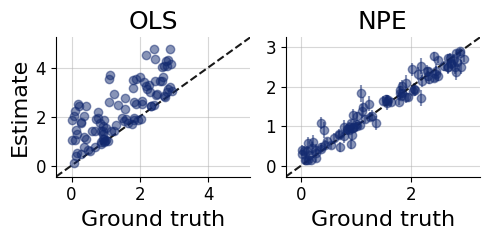

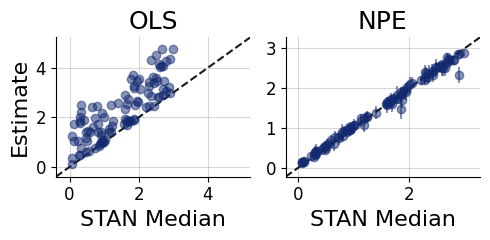

In [20]:
bf_samples = posterior_samples['prior_draws'][:, :, :1]
stan_samples = estimates_STAN[:, -300:, :1]
ols_samples = np.repeat(estimates_OLS, 300, axis=1)

estimates = np.concatenate((ols_samples, bf_samples, stan_samples), axis=-1)
target = np.stack((valid_data['prior_draws'][:, 0], valid_data['prior_draws'][:, 0],
                   valid_data['prior_draws'][:, 0]
                   ), axis=-1)
fig = bf.diagnostics.recovery(estimates, target, variable_names=['OLS', 'STAN', 'NPE'])

estimates = np.concatenate((ols_samples, bf_samples), axis=-1)
target = np.stack((valid_data['prior_draws'][:, 0], valid_data['prior_draws'][:, 0]), axis=-1)
fig = bf.diagnostics.recovery(estimates, target, variable_names=['OLS', 'NPE'], figsize=(5, 2.5), add_corr=False)
#fig.savefig('plots/unobserved_variable_true.pdf')

estimates = np.concatenate((ols_samples, bf_samples), axis=-1)
target = np.stack((np.median(stan_samples, axis=1)[:, 0], np.median(stan_samples, axis=1)[:, 0]), axis=-1)
fig = bf.diagnostics.recovery(estimates, target, variable_names=['OLS', 'NPE'], xlabel='STAN Median', figsize=(5, 2.5), add_corr=False)
#fig.savefig('plots/unobserved_variable_stan.pdf')

In [ ]:
from scipy.stats import wasserstein_distance_nd

In [ ]:
wd = [wasserstein_distance_nd(estimates_STAN[i][-300:], posterior_samples['prior_draws'][i]) for i in range(100)]
wd